In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

In [8]:

from src.dsets import getCandidateInfoList, LunaDataset

candidateInfo_list = getCandidateInfoList(requireOnDisk_bool=False)
candidateInfo_list[0]

CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))

In [9]:
from src.vis import findPositiveSamples, showCandidate
positiveSample_list = findPositiveSamples()

2025-04-13 22:18:57,251 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.LunaDataset object at 0x0000029D065514F0>: 551065 training samples, 549714 neg, 1351 pos, unbalanced ratio


0 CandidateInfoTuple(isNodule_bool=True, diameter_mm=0.0, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.309672797925724868457151381131', center_xyz=(48.47, -82.12, -168.75))
1 CandidateInfoTuple(isNodule_bool=True, diameter_mm=0.0, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.280072876841890439628529365478', center_xyz=(115.43, -129.17, -249.06))
2 CandidateInfoTuple(isNodule_bool=True, diameter_mm=4.991628467, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.215104063467523905369326175410', center_xyz=(-100.824552733, 15.1219714715, -181.592236964))
3 CandidateInfoTuple(isNodule_bool=True, diameter_mm=4.97609166, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.154703816225841204080664115280', center_xyz=(-97.9749488649, -34.2856635271, -221.002217417))
4 CandidateInfoTuple(isNodule_bool=True, diameter_mm=22.22543938, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.286422846896797433168187085942', center_xyz=(-89.5875500717, 11.3033645407, -70.9842087538))
5 CandidateInfoTuple(isNodule_bool=

In [10]:
augmentation_dict = {}
augmentation_list = [
    ('None', {}),
    ('flip', {'flip': True}),
    ('offset', {'offset': 0.1}),
    ('scale', {'scale': 0.2}),
    ('rotate', {'rotate': True}),
    ('noise', {'noise': 25.0}),    
]
ds_list = [
    LunaDataset(sortby_str='label_and_size', augmentation_dict=augmentation_dict) 
    for title_str, augmentation_dict in augmentation_list
]

all_dict = {}
for title_str, augmentation_dict in augmentation_list:
    all_dict.update(augmentation_dict)
all_ds = LunaDataset(sortby_str='label_and_size', augmentation_dict=all_dict)

augmentation_list.extend([('All', augmentation_dict)] * 3)
ds_list.extend([all_ds] * 3)



2025-04-13 22:18:57,356 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.LunaDataset object at 0x0000029D0651D160>: 551065 training samples, 549714 neg, 1351 pos, unbalanced ratio
2025-04-13 22:18:57,424 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.LunaDataset object at 0x0000029D02E1C2C0>: 551065 training samples, 549714 neg, 1351 pos, unbalanced ratio
2025-04-13 22:18:57,492 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.LunaDataset object at 0x0000029D0651CB00>: 551065 training samples, 549714 neg, 1351 pos, unbalanced ratio
2025-04-13 22:18:57,559 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.LunaDataset object at 0x0000029D0651DC10>: 551065 training samples, 549714 neg, 1351 pos, unbalanced ratio
2025-04-13 22:18:57,639 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.LunaDataset object at 0x0000029D0651F0E0>: 551065 training samples, 549714 neg, 1351 pos, unbalanced ratio
2025-04-13 22:18:57,734 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.Lun

torch.Size([1, 32, 48, 48]) (tensor([0, 1]), '1.3.6.1.4.1.14519.5.2.1.6279.6001.173106154739244262091404659845', tensor([110, 355, 189]))


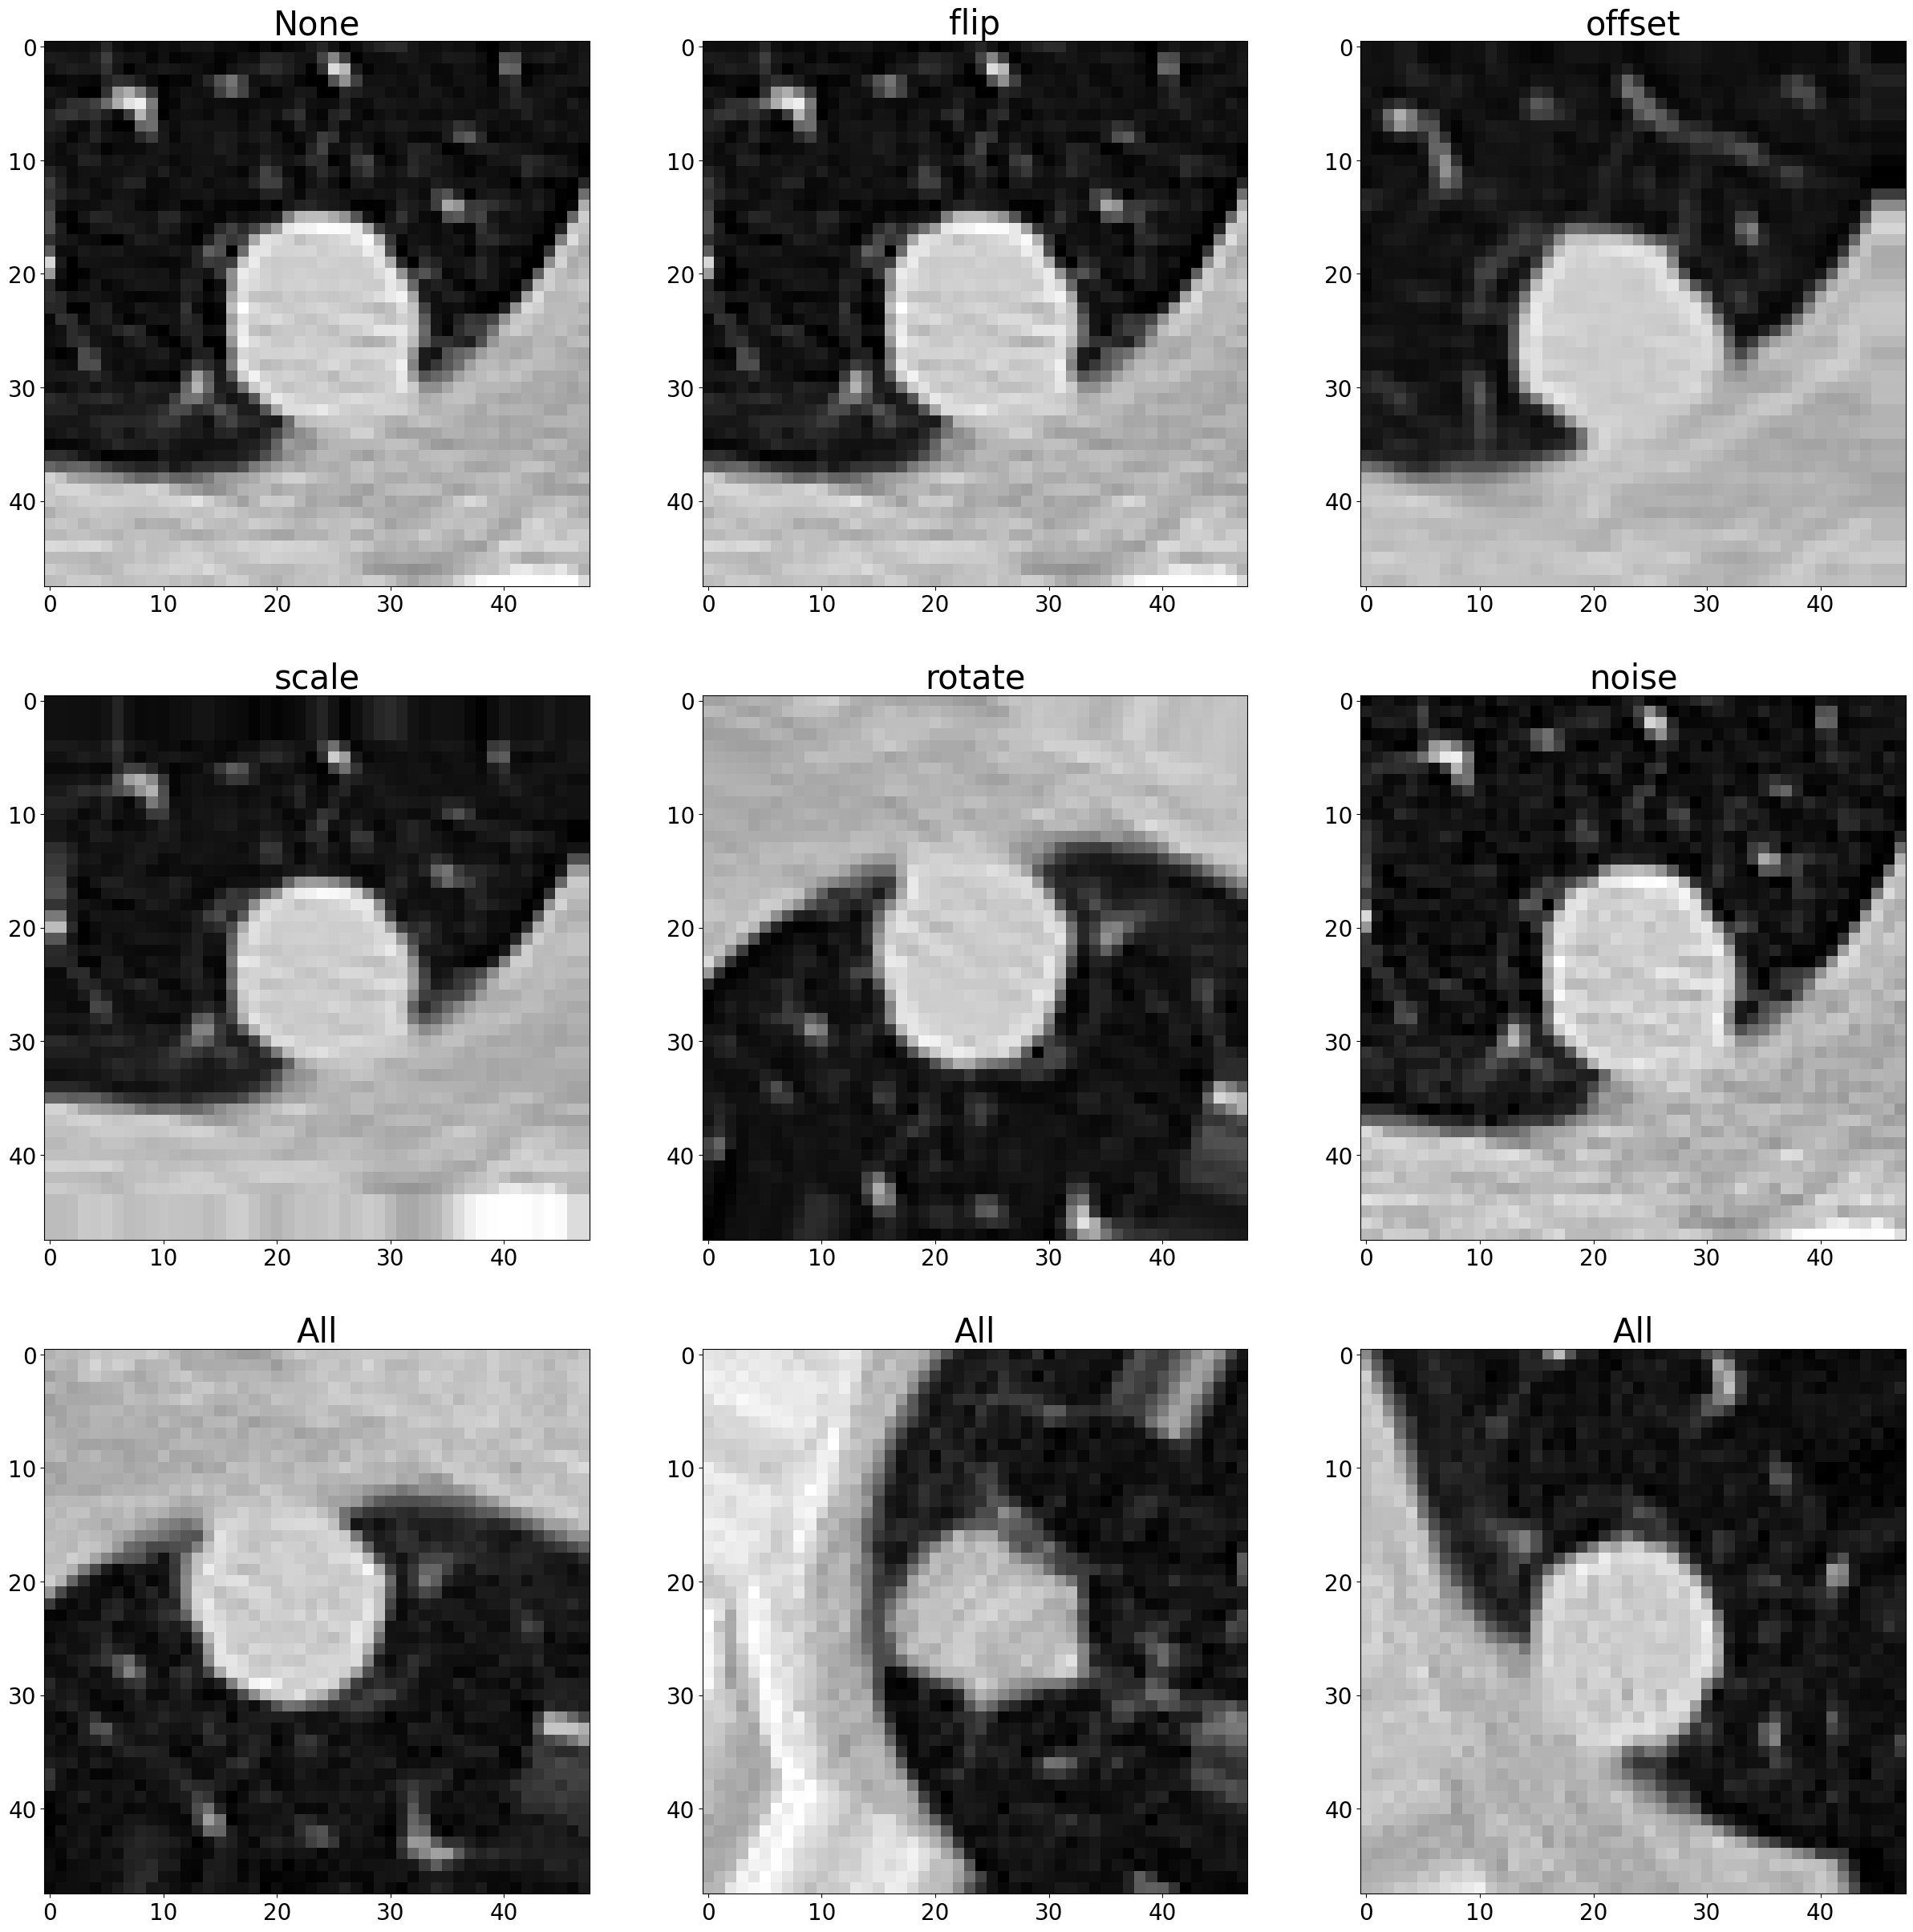

In [11]:
sample_ndx = 100
sample_ndx = 154
sample_ndx = 155


sample_tup = all_ds[sample_ndx]
print(sample_tup[0].shape, sample_tup[1:])

fig = plt.figure(figsize=(30, 30))

clim=(-1000.0, 300)

for i, ((title_str, _), ds) in enumerate(zip(augmentation_list, ds_list)):
    sample_tup = ds[sample_ndx]
    subplot = fig.add_subplot(3, 3, i+1)
    subplot.set_title(title_str, fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(sample_tup[0][0][16], clim=clim, cmap='gray')



2025-04-13 22:19:00,017 INFO     pid:15424 src.dsets:269:__init__ <src.dsets.LunaDataset object at 0x0000029D04567B00>: 393 training samples, 381 neg, 12 pos, unbalanced ratio


1.3.6.1.4.1.14519.5.2.1.6279.6001.280072876841890439628529365478 8 False [8, 9, 46, 66, 119, 210, 256, 260, 275, 305, 310, 333]


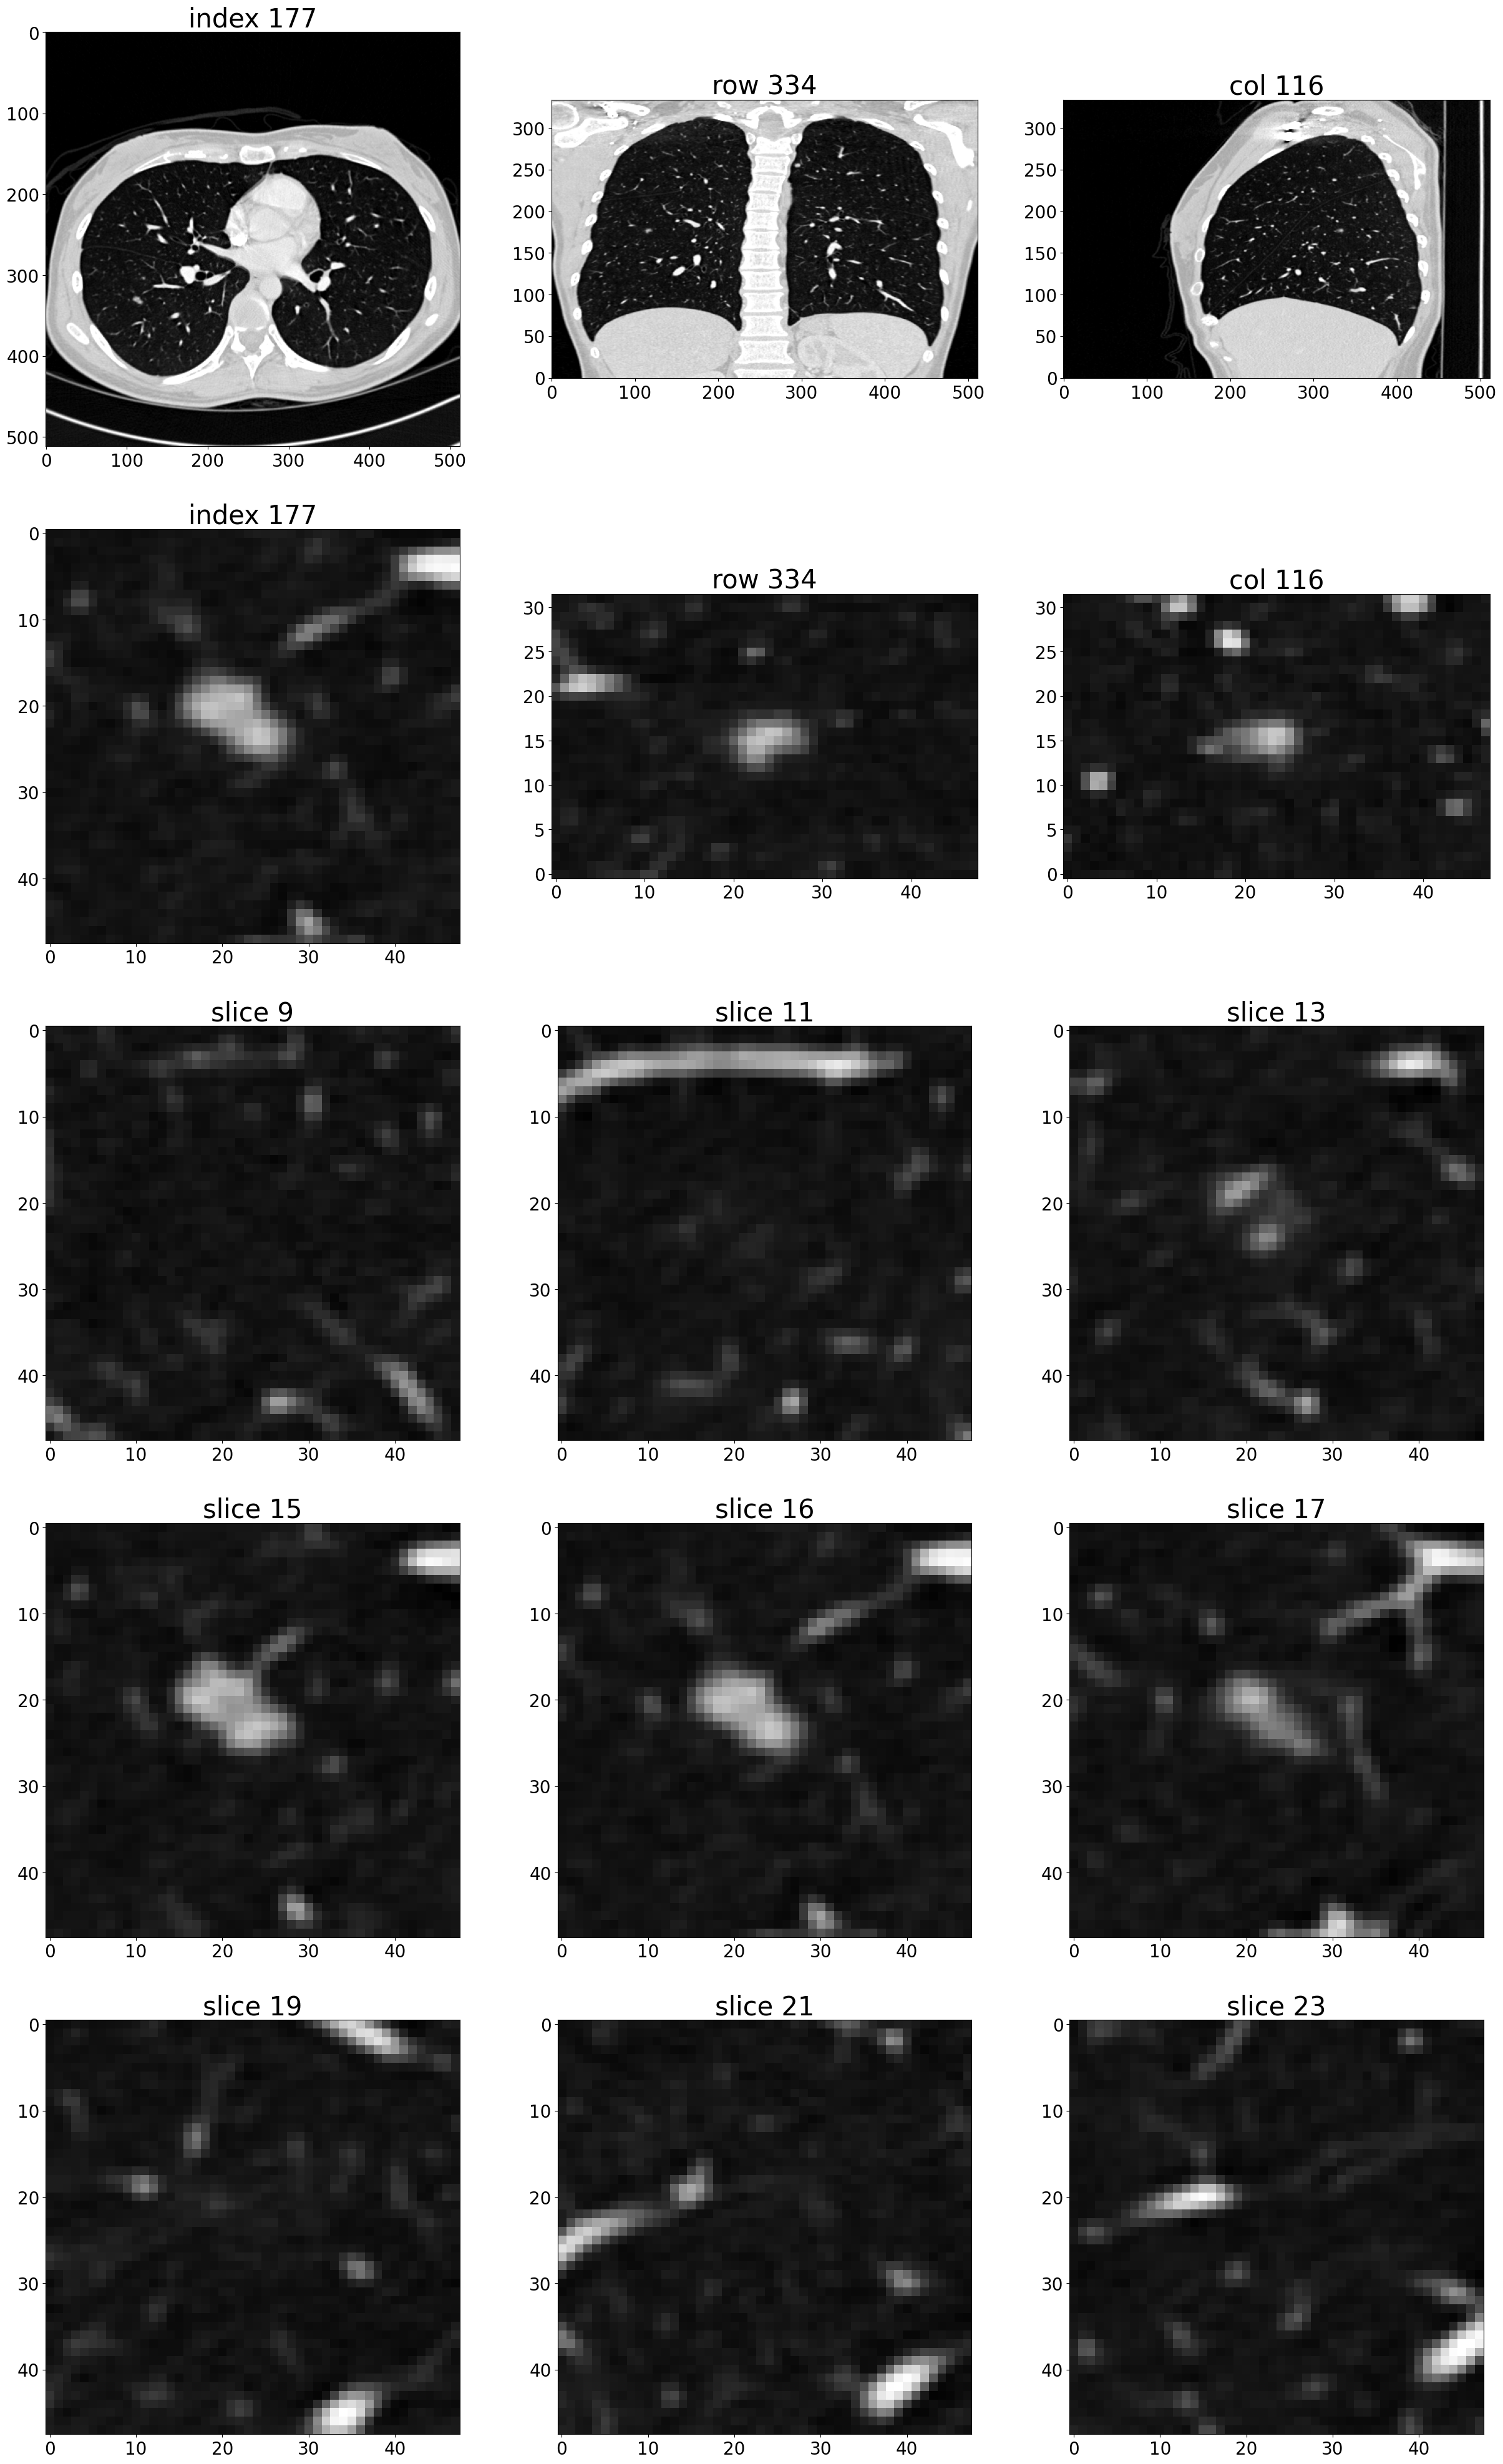

In [12]:
series_uid = positiveSample_list[1][2]
showCandidate(series_uid)